In [1]:
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt

# ajuste se o caminho estiver diferente no seu Colab/Drive
DATASET_ROOT = Path("/content/drive/MyDrive/unet_dataset_mt2023_v2/shards")
assert DATASET_ROOT.exists(), f"não achei: {DATASET_ROOT}"

SPLITS = ["train", "val", "test"]
for s in SPLITS:
    p = DATASET_ROOT / s
    assert p.exists(), f"não achei split: {p}"

print("OK. dataset:", DATASET_ROOT)
print({s: len(list((DATASET_ROOT/s).glob("*.npz"))) for s in SPLITS})

OK. dataset: /content/drive/MyDrive/unet_dataset_mt2023_v2/shards
{'train': 94, 'val': 19, 'test': 19}


In [2]:
def list_shards(split: str):
    shards = sorted((DATASET_ROOT / split).glob("*.npz"))
    return shards

def load_shard(npz_path: Path):
    z = np.load(npz_path, allow_pickle=True)
    keys = list(z.files)
    # esperamos algo como X/Y (varia conforme como você salvou)
    # vamos tentar detectar automaticamente
    X_key = "X" if "X" in keys else ("x" if "x" in keys else None)
    Y_key = "Y" if "Y" in keys else ("y" if "y" in keys else None)
    M_key = "meta" if "meta" in keys else ("metadata" if "metadata" in keys else None)

    if X_key is None or Y_key is None:
        raise ValueError(f"não achei X/Y em {npz_path.name}. keys={keys}")

    X = z[X_key]  # (N, H, W, C) esperado
    Y = z[Y_key]  # (N, H, W) esperado
    meta = z[M_key] if M_key is not None else None
    return X, Y, meta, keys

for s in SPLITS:
    shards = list_shards(s)
    print(s, "shards:", len(shards), "ex:", shards[0].name if shards else None)

train shards: 94 ex: shard_0000.npz
val shards: 19 ex: shard_0000.npz
test shards: 19 ex: shard_0000.npz


In [3]:
def quick_check_split(split: str, shard_idx: int = 0):
    shards = list_shards(split)
    assert len(shards) > 0, f"sem shards em {split}"
    npz = shards[shard_idx]
    X, Y, meta, keys = load_shard(npz)

    print(f"\n[{split}] shard={npz.name}")
    print("keys:", keys)
    print("X shape:", X.shape, "dtype:", X.dtype)
    print("Y shape:", Y.shape, "dtype:", Y.dtype)

    # checa valores de Y
    u = np.unique(Y)
    print("Y unique (até 20):", u[:20], "total uniques:", len(u))

    # checa range de X (pode estar u16 escalado)
    x_min = float(np.nanmin(X))
    x_max = float(np.nanmax(X))
    print("X min/max:", x_min, x_max)

    if meta is not None:
        print("meta type:", type(meta), "len:", len(meta))
        try:
            print("meta[0] exemplo:", meta[0])
        except Exception as e:
            print("meta preview falhou:", e)

for s in SPLITS:
    quick_check_split(s, shard_idx=0)


[train] shard=shard_0000.npz
keys: ['X', 'Y', 'meta']
X shape: (32, 256, 256, 21) dtype: uint16
Y shape: (32, 256, 256) dtype: uint8
Y unique (até 20): [  0 255] total uniques: 2
X min/max: 0.0 10000.0
meta type: <class 'numpy.ndarray'> len: 32
meta[0] exemplo: {'tile': 'unet_mt_2023_mosaic_x-59p00_y-12p00.tif', 'key': 'x-59p00_y-12p00', 'split': 'train', 'kind': 'neg', 'x0': 2488, 'y0': 3022}

[val] shard=shard_0000.npz
keys: ['X', 'Y', 'meta']
X shape: (32, 256, 256, 21) dtype: uint16
Y shape: (32, 256, 256) dtype: uint8
Y unique (até 20): [  0   1 255] total uniques: 3
X min/max: 0.0 10000.0
meta type: <class 'numpy.ndarray'> len: 32
meta[0] exemplo: {'tile': 'unet_mt_2023_mosaic_x-59p00_y-12p00.tif', 'key': 'x-59p00_y-12p00', 'split': 'val', 'kind': 'pos', 'x0': 3372, 'y0': 2977}

[test] shard=shard_0000.npz
keys: ['X', 'Y', 'meta']
X shape: (32, 256, 256, 21) dtype: uint16
Y shape: (32, 256, 256) dtype: uint8
Y unique (até 20): [  1 255] total uniques: 2
X min/max: 0.0 10000.0
me

In [4]:
# bandas do seu mosaico (ordem do export do GEE) — precisa bater com o que foi salvo no shard!
BANDS = [
    "BLUE_median","BLUE_p20","BLUE_p80",
    "GREEN_median","GREEN_p20","GREEN_p80",
    "RED_median","RED_p20","RED_p80",
    "NIR_median","NIR_p20","NIR_p80",
    "SWIR1_median","SWIR1_p20","SWIR1_p80",
    "SWIR2_median","SWIR2_p20","SWIR2_p80",
    "EVI2_median","EVI2_p20","EVI2_p80"
]
BAND_TO_IDX = {b:i for i,b in enumerate(BANDS)}

# rgb de inspeção (igual seu estilo NIR/SWIR1/RED)
RGB_BANDS = ("NIR_median", "SWIR1_median", "RED_median")

def to_float01(X_patch: np.ndarray, scale_u16: float = 10000.0):
    # se X já for float, retorna como está
    if np.issubdtype(X_patch.dtype, np.floating):
        return X_patch
    return X_patch.astype(np.float32) / scale_u16

def make_rgb(X_patch: np.ndarray, scale_u16: float = 10000.0):
    Xf = to_float01(X_patch, scale_u16=scale_u16)
    idx = [BAND_TO_IDX[b] for b in RGB_BANDS]
    rgb = Xf[..., idx]
    # clamp para visual
    rgb = np.clip(rgb, 0, 1)
    return rgb

In [5]:
def plot_patch(X_patch, Y_patch, title="", scale_u16=10000.0):
    rgb = make_rgb(X_patch, scale_u16=scale_u16)

    # máscara para overlay: milho=1 (verde), não-milho=0 (transparente), ignore=255 (vermelho pontilhado)
    milho = (Y_patch == 1)
    ign   = (Y_patch == 255)

    fig, ax = plt.subplots(1, 3, figsize=(14, 5))
    ax[0].imshow(rgb)
    ax[0].set_title("RGB (NIR/SWIR1/RED)")
    ax[0].axis("off")

    ax[1].imshow(Y_patch, vmin=0, vmax=255)
    ax[1].set_title("GT raw (0/1/255)")
    ax[1].axis("off")

    ax[2].imshow(rgb)
    ax[2].imshow(milho.astype(np.uint8), alpha=0.35)  # overlay simples (sem cor fixa)
    # ign como contorno leve
    ax[2].imshow(ign.astype(np.uint8), alpha=0.15)
    ax[2].set_title("Overlay (milho + ignore)")
    ax[2].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

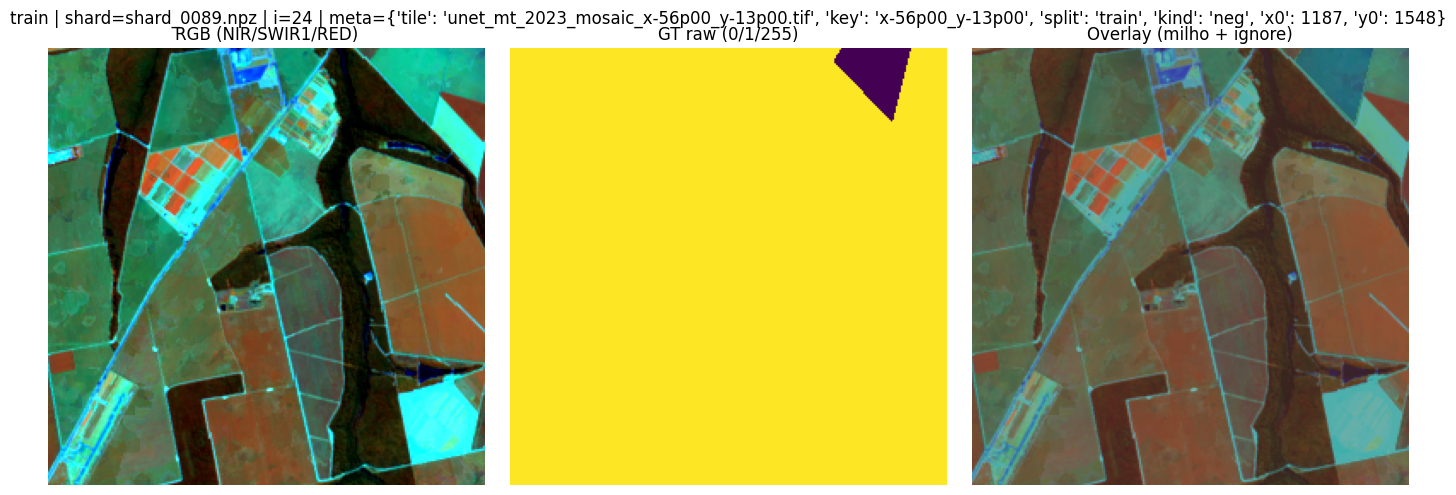

In [6]:
def sample_random_patch(split: str, scale_u16=10000.0):
    shards = list_shards(split)
    assert len(shards) > 0, f"sem shards em {split}"
    npz = random.choice(shards)
    X, Y, meta, keys = load_shard(npz)

    n = X.shape[0]
    i = random.randrange(n)

    # título com metadados (se existirem)
    t = f"{split} | shard={npz.name} | i={i}"
    if meta is not None:
        try:
            t += f" | meta={meta[i]}"
        except Exception:
            pass

    plot_patch(X[i], Y[i], title=t, scale_u16=scale_u16)

# teste rápido
sample_random_patch("train")

In [7]:
def view_n(split: str, n: int = 5, scale_u16=10000.0, seed: int = 0):
    random.seed(seed)
    for k in range(n):
        sample_random_patch(split, scale_u16=scale_u16)

view_n("train", n=5, seed=1)
view_n("val",   n=3, seed=2)
view_n("test",  n=3, seed=3)


Output hidden; open in https://colab.research.google.com to view.

In [8]:
def scan_patch_stats(split: str, max_patches: int = 400):
    shards = list_shards(split)
    total_seen = 0
    frac_milho = []

    for npz in shards:
        X, Y, meta, keys = load_shard(npz)
        for i in range(Y.shape[0]):
            y = Y[i]
            valid = (y != 255)
            if valid.sum() == 0:
                frac = 0.0
            else:
                frac = float((y[valid] == 1).sum()) / float(valid.sum())
            frac_milho.append(frac)
            total_seen += 1
            if total_seen >= max_patches:
                break
        if total_seen >= max_patches:
            break

    frac_milho = np.array(frac_milho, dtype=np.float32)
    print(f"[{split}] patches analisados:", len(frac_milho))
    print("frac milho: min/med/max =", float(frac_milho.min()), float(np.median(frac_milho)), float(frac_milho.max()))
    print("frac milho > 0:", int((frac_milho > 0).sum()))
    return frac_milho

_ = scan_patch_stats("train", max_patches=600)
_ = scan_patch_stats("val",   max_patches=300)
_ = scan_patch_stats("test",  max_patches=300)

[train] patches analisados: 600
frac milho: min/med/max = 0.0 0.1776425987482071 1.0
frac milho > 0: 310
[val] patches analisados: 300
frac milho: min/med/max = 0.0 0.0 1.0
frac milho > 0: 103
[test] patches analisados: 300
frac milho: min/med/max = 0.0 1.0 1.0
frac milho > 0: 217


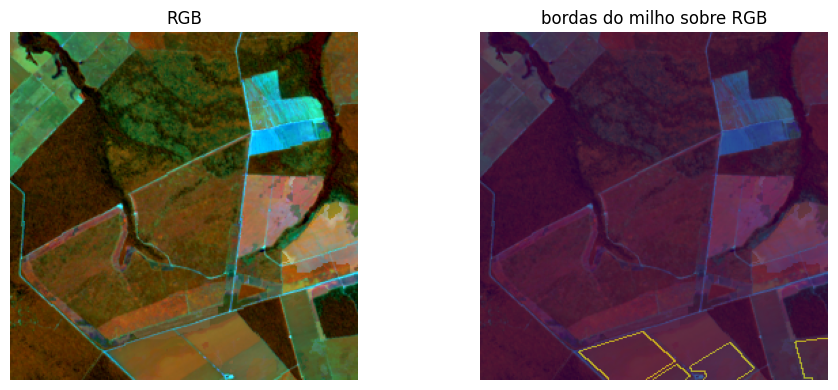

In [9]:
def edge_map(mask01: np.ndarray):
    # borda simples por diferença em 4-neighbors
    m = mask01.astype(np.uint8)
    e = np.zeros_like(m)
    e[:-1, :] |= (m[:-1, :] != m[1:, :])
    e[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return e

def plot_with_edges(split: str, scale_u16=10000.0):
    shards = list_shards(split)
    npz = random.choice(shards)
    X, Y, meta, keys = load_shard(npz)
    i = random.randrange(X.shape[0])

    rgb = make_rgb(X[i], scale_u16=scale_u16)
    y = Y[i]
    milho = (y == 1)
    ed = edge_map(milho)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(rgb); ax[0].axis("off"); ax[0].set_title("RGB")
    ax[1].imshow(rgb)
    ax[1].imshow(ed.astype(np.uint8), alpha=0.6)
    ax[1].axis("off"); ax[1].set_title("bordas do milho sobre RGB")
    plt.tight_layout()
    plt.show()

plot_with_edges("train")

In [10]:
from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/unet_dataset_mt2023_v2")
assert ROOT.exists(), f"não achei {ROOT}"

# acha npz em qualquer subpasta e tenta inferir split pelo caminho
npz_all = sorted(ROOT.rglob("*.npz"))
print("npz encontrados:", len(npz_all))
assert len(npz_all) > 0, "nenhum .npz encontrado"

def infer_split(p: Path):
    parts = [x.lower() for x in p.parts]
    for s in ["train","val","test"]:
        if s in parts:
            return s
    return "unknown"

# pega 1 shard de cada split (se existir)
pick = {}
for p in npz_all:
    s = infer_split(p)
    if s not in pick:
        pick[s] = p
    if all(k in pick for k in ["train","val","test"]):
        break

print("shards escolhidos:", {k: v.name for k,v in pick.items()})

def load_npz(npz_path: Path):
    z = np.load(npz_path, allow_pickle=True)
    keys = list(z.files)
    Xk = "X" if "X" in keys else ("x" if "x" in keys else None)
    Yk = "Y" if "Y" in keys else ("y" if "y" in keys else None)
    Mk = "meta" if "meta" in keys else ("metadata" if "metadata" in keys else None)
    assert Xk and Yk, f"não achei X/Y. keys={keys}"
    X = z[Xk]
    Y = z[Yk]
    meta = z[Mk] if Mk else None
    return X, Y, meta, keys

for s, p in pick.items():
    X, Y, meta, keys = load_npz(p)
    flat = Y.reshape(-1)
    vals, cnts = np.unique(flat, return_counts=True)
    d = dict(zip(vals.tolist(), cnts.tolist()))
    print("\n---", s, p.name, "---")
    print("keys:", keys)
    print("X:", X.shape, X.dtype, " Y:", Y.shape, Y.dtype)
    print("unique(Y):", d)
    print("pct==1:", float((flat==1).mean()), " pct==0:", float((flat==0).mean()), " pct==255:", float((flat==255).mean()))


npz encontrados: 132
shards escolhidos: {'test': 'shard_0000.npz', 'train': 'shard_0000.npz', 'val': 'shard_0000.npz'}

--- test shard_0000.npz ---
keys: ['X', 'Y', 'meta']
X: (32, 256, 256, 21) uint16  Y: (32, 256, 256) uint8
unique(Y): {1: 51409, 255: 2045743}
pct==1: 0.024513721466064453  pct==0: 0.0  pct==255: 0.9754862785339355

--- train shard_0000.npz ---
keys: ['X', 'Y', 'meta']
X: (32, 256, 256, 21) uint16  Y: (32, 256, 256) uint8
unique(Y): {0: 71001, 255: 2026151}
pct==1: 0.0  pct==0: 0.03385591506958008  pct==255: 0.9661440849304199

--- val shard_0000.npz ---
keys: ['X', 'Y', 'meta']
X: (32, 256, 256, 21) uint16  Y: (32, 256, 256) uint8
unique(Y): {0: 17279, 1: 21677, 255: 2058196}
pct==1: 0.01033639907836914  pct==0: 0.008239269256591797  pct==255: 0.9814243316650391


In [12]:
import rasterio as rio
import numpy as np
from pathlib import Path

# pega um shard (preferência: train)
shard_path = pick.get("train") or next(iter(pick.values()))
X, Y, meta, keys = load_npz(shard_path)

print("shard:", shard_path.name)
assert meta is not None, "esse shard não tem meta; preciso do meta para achar o tile"

# meta pode ser array de dicts (object). pega o 1o
m0 = meta[0].item() if hasattr(meta[0], "item") else meta[0]
print("meta[0]:", m0)

tile_name = m0.get("tile")
assert tile_name, "meta não tem 'tile'"

# tenta achar GT tif pelo nome, tanto no local quanto no drive
SEARCH_ROOTS = [
    Path("/content"),  # inclui /content/gee_exports_local etc.
    Path("/content/drive/MyDrive")
]

gt_candidates = []
for r in SEARCH_ROOTS:
    gt_candidates += list(r.rglob(tile_name.replace("mosaic", "gtv2")))

print("gt candidates:", len(gt_candidates))
assert len(gt_candidates) > 0, "não achei gt tif correspondente. ajuste SEARCH_ROOTS ou o padrão de nome"

gt_path = gt_candidates[0]
print("usando:", gt_path)

with rio.open(gt_path) as ds:
    print("GT tif CRS:", ds.crs, "shape:", (ds.height, ds.width), "count(bands):", ds.count, "dtype:", ds.dtypes)
    for b in range(1, ds.count+1):
        arr = ds.read(b)
        # bincount rápido (assume uint8/uint16 pequeno); fallback p/ unique
        if np.issubdtype(arr.dtype, np.integer) and arr.max() <= 255:
            bc = np.bincount(arr.reshape(-1).astype(np.uint16), minlength=256)
            print(f"band {b}: count(0)={int(bc[0])} count(1)={int(bc[1])} count(255)={int(bc[255])} max={int(arr.max())}")
        else:
            vals, cnts = np.unique(arr, return_counts=True)
            d = dict(zip(vals.tolist(), cnts.tolist()))
            print(f"band {b}: unique sample:", list(d.items())[:10], "max:", arr.max())


shard: shard_0000.npz
meta[0]: {'tile': 'unet_mt_2023_mosaic_x-59p00_y-12p00.tif', 'key': 'x-59p00_y-12p00', 'split': 'train', 'kind': 'neg', 'x0': 2488, 'y0': 3022}
gt candidates: 2
usando: /content/drive/MyDrive/GEE_Exports/unet_mt_2023_gtv2_x-59p00_y-12p00.tif
GT tif CRS: EPSG:4326 shape: (3711, 3712) count(bands): 3 dtype: ('uint8', 'uint8', 'uint8')
band 1: count(0)=5998 count(1)=0 count(255)=13769234 max=255
band 2: count(0)=0 count(1)=3792 count(255)=13771440 max=255
band 3: count(0)=0 count(1)=2609 count(255)=13772623 max=255


In [14]:
from pathlib import Path
import numpy as np
import rasterio as rio

# ajuste se seu dataset estiver em outro lugar
ROOT = Path("/content/drive/MyDrive/unet_dataset_mt2023_v2")
shard = next(iter(sorted(ROOT.rglob("shard_0000.npz"))), None)
assert shard is not None, "não achei shard_0000.npz"

z = np.load(shard, allow_pickle=True)
X = z["X"]; Y = z["Y"]; meta = z["meta"]
m0 = meta[0].item() if hasattr(meta[0], "item") else meta[0]
print("shard:", shard)
print("meta[0]:", m0)

key = m0.get("key")
assert key, "meta não tem 'key'"

gt_name = f"unet_mt_2023_gtv2_{key}.tif"
print("gt_name esperado:", gt_name)

# tente localizar o GT no /content e no Drive
cands = []
for base in [Path("/content"), Path("/content/drive/MyDrive")]:
    cands += list(base.rglob(gt_name))

print("GT candidates:", len(cands))
assert len(cands) > 0, "não achei o GT tif correspondente (procurei em /content e /content/drive/MyDrive)"

gt_path = cands[0]
print("usando:", gt_path)

def count_vals(ds, band, targets=(0,1,255)):
    counts = {t: 0 for t in targets}
    for _, w in ds.block_windows(band):
        a = ds.read(band, window=w)
        for t in targets:
            counts[t] += int((a == t).sum())
    return counts

with rio.open(gt_path) as ds:
    print("GT:", ds.count, "bands | dtype:", ds.dtypes, "| CRS:", ds.crs, "| shape:", (ds.height, ds.width))
    for b in range(1, ds.count+1):
        c = count_vals(ds, b)
        total = ds.height * ds.width
        print(f"band {b}: count0={c[0]} count1={c[1]} count255={c[255]}  frac1={c[1]/total:.6f}  frac255={c[255]/total:.6f}")


shard: /content/drive/MyDrive/unet_dataset_mt2023_v2/shards/test/shard_0000.npz
meta[0]: {'tile': 'unet_mt_2023_mosaic_x-59p00_y-12p00.tif', 'key': 'x-59p00_y-12p00', 'split': 'test', 'kind': 'pos', 'x0': 2840, 'y0': 2450}
gt_name esperado: unet_mt_2023_gtv2_x-59p00_y-12p00.tif
GT candidates: 2
usando: /content/drive/MyDrive/GEE_Exports/unet_mt_2023_gtv2_x-59p00_y-12p00.tif
GT: 3 bands | dtype: ('uint8', 'uint8', 'uint8') | CRS: EPSG:4326 | shape: (3711, 3712)
band 1: count0=5998 count1=0 count255=13769234  frac1=0.000000  frac255=0.999565
band 2: count0=0 count1=3792 count255=13771440  frac1=0.000275  frac255=0.999725
band 3: count0=0 count1=2609 count255=13772623  frac1=0.000189  frac255=0.999811
